# M4 (continued) — **Final 80-epoch training from the best hyperparameters**

Your tuning sweep finished; the winning config was selected. The final 80-epoch training then ran
out of compute mid-run. This short notebook does **only that leftover step** — and it saves a
checkpoint to Drive **every epoch**, so if compute cuts out again you just re-run and it **resumes
from where it stopped** instead of restarting.

**Winner from your sweep:** `t3_lr001_adamw` → `lr0=0.001, optimizer=AdamW, cos_lr=True, close_mosaic=10`
(read automatically from `trial_results.csv` below; you don't type it by hand).

## Where the best hyperparameters live & which file to pick

* **Best hyperparameters** are stored in **`trial_results.csv`** → column `config` → row of the
  winning trial. They are **not** inside any `.pt` file. (`best_hyperparameters.yaml` gets written at
  the very end of *this* notebook — it didn't exist before.)
* **Which `.pt` to start from?** *None of the trial files.* The trial `best.pt`/`last.pt` files were
  30-epoch screening runs, kept only for scoring. The final model trains **fresh from the standard
  pretrained `yolov8n.pt`** with the winning config applied.
* **The file you keep at the end** is produced here: `deliverables/yolov8n_best.pt` (the 80-epoch
  model) plus `deliverables/best_hyperparameters.yaml`.

## 1 · Environment setup

In [ ]:
%pip -q install "ultralytics>=8.3.0" pandas matplotlib pyyaml tqdm >/dev/null 2>&1

import os, random, shutil, yaml, json, time, warnings, zipfile
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); os.environ["PYTHONHASHSEED"] = str(SEED)

import torch
from ultralytics import YOLO
import ultralytics

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Ultralytics :", ultralytics.__version__)
print("Torch       :", torch.__version__)
print("Device      :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
if DEVICE == "cpu":
    print("\n[!] No GPU — enable it: Runtime → Change runtime type → GPU.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics : 8.4.107
Torch       : 2.11.0+cu128
Device      : Tesla T4


## 2 · Mount Drive & load the dataset
Point `DATASET_PATH` at the dataset in this account's Drive (folder or `.zip`). If the path is off,
the loader auto-searches My Drive.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# ← EDIT if needed (folder OR .zip). Leave as-is to auto-search My Drive.
DATASET_PATH = "/content/drive/MyDrive/final_training_for_m4/smoking_drinking_yolo_balanced (1) (1).zip"

def _looks_like_dataset(d: Path) -> bool:
    return (d / "data.yaml").exists() and (d / "images" / "train").exists()

def _find_dataset(root: Path):
    root = Path(root)
    if _looks_like_dataset(root): return root
    if not root.exists(): return None
    for d in sorted([p for p in root.iterdir() if p.is_dir()]):
        if _looks_like_dataset(d): return d
        for dd in sorted([p for p in d.iterdir() if p.is_dir()]):
            if _looks_like_dataset(dd): return dd
    return None

src = Path(DATASET_PATH)
if src.exists() and src.is_dir() and _looks_like_dataset(src):
    DATASET_DIR = src.resolve()
elif src.exists() and (src.suffix.lower() == ".zip" or src.is_file()):
    DATASET_DIR = (Path("/content") / Path(DATASET_PATH).stem).resolve()
    if not _looks_like_dataset(DATASET_DIR):
        print(f"Unzipping {src} → {DATASET_DIR} …")
        shutil.unpack_archive(str(src), str(DATASET_DIR))
    ff = _find_dataset(DATASET_DIR)
    if ff: DATASET_DIR = ff.resolve()
else:
    print("DATASET_PATH not found — searching My Drive …")
    found = _find_dataset(Path("/content/drive/MyDrive"))
    assert found is not None, "No dataset (data.yaml + images/train) found. Set DATASET_PATH."
    DATASET_DIR = found.resolve()

assert _looks_like_dataset(DATASET_DIR), f"data.yaml / images/train not found under {DATASET_DIR}."
DATA_YAML = DATASET_DIR / "data.yaml"
_meta = yaml.safe_load(DATA_YAML.read_text())
CLASS_NAMES = _meta["names"]
CLASS_NAMES = list(CLASS_NAMES.values()) if isinstance(CLASS_NAMES, dict) else list(CLASS_NAMES)
NC = len(CLASS_NAMES)
print("Dataset dir :", DATASET_DIR)
print("Classes     :", {i: n for i, n in enumerate(CLASS_NAMES)})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping /content/drive/MyDrive/final_training_for_m4/smoking_drinking_yolo_balanced (1) (1).zip → /content/smoking_drinking_yolo_balanced (1) (1) …
Dataset dir : /content/smoking_drinking_yolo_balanced (1) (1)
Classes     : {0: 'smoking', 1: 'drinking'}


## 3 · Read the winning hyperparameters from `trial_results.csv`
This is the source of truth. It finds your tuning folder, shows the finished trials, and picks the
winner by val mAP@50-95 automatically. If it can't find the CSV, it falls back to the known winner.

In [ ]:
# CKPT_DIR = this account's tuning folder (where the sweep saved results).
CKPT_DIR = Path("/content/drive/MyDrive/final_training_for_m4")

def _find_results_csv():
    if (CKPT_DIR / "trial_results.csv").exists():
        return CKPT_DIR / "trial_results.csv"
    root = Path("/content/drive/MyDrive")
    hits = list(root.rglob("trial_results.csv")) if root.exists() else []
    return hits[0] if hits else None

# Fallback winner (from your completed sweep) if the CSV can't be located.
FINAL_CFG = {"lr0": 0.001, "optimizer": "AdamW", "cos_lr": True, "close_mosaic": 10}
BEST_TRIAL = "t3_lr001_adamw"

csv = _find_results_csv()
if csv is not None:
    globals()["CKPT_DIR"] = csv.parent           # anchor everything to the real folder
    df = pd.read_csv(csv)
    df["mAP50-95"] = pd.to_numeric(df["mAP50-95"], errors="coerce")
    print("Reading best hyperparameters from:", csv, "\n")
    show = df[["trial", "mAP50-95"]].copy()
    show["config"] = df["config"]
    from IPython.display import display; display(show)
    cand = df[~df["trial"].isin(["yolov8n_baseline", "yolov8n_FINAL"])]
    if len(cand) and cand["mAP50-95"].notna().any():
        row = cand.loc[cand["mAP50-95"].idxmax()]
        BEST_TRIAL = row["trial"]
        FINAL_CFG = json.loads(row["config"])
else:
    print("[!] trial_results.csv not found — using the known winner as a fallback.")

print("\nWINNING TRIAL :", BEST_TRIAL)
print("BEST CONFIG   :", FINAL_CFG)
print("Stored in     :", (csv if csv else "trial_results.csv (config column, winning row)"))
print("CKPT_DIR      :", CKPT_DIR)

TRIALS_DIR = CKPT_DIR / "trials"
DELIV_DIR  = CKPT_DIR / "deliverables"
DELIV_DIR.mkdir(parents=True, exist_ok=True)

Reading best hyperparameters from: /content/drive/MyDrive/final_training_for_m4/trial_results.csv 



,trial,mAP50-95,config
0,yolov8n_baseline,0.415422,{}
1,t1_lr01_sgd,0.405613,"{""lr0"": 0.01, ""optimizer"": ""SGD"", ""cos_lr"": fa..."
2,t2_lr005_sgd_cos,0.411612,"{""lr0"": 0.005, ""optimizer"": ""SGD"", ""cos_lr"": t..."
3,t3_lr001_adamw,0.424529,"{""lr0"": 0.001, ""optimizer"": ""AdamW"", ""cos_lr"":..."
4,t4_lr005_adamw_wd,0.377453,"{""lr0"": 0.005, ""optimizer"": ""AdamW"", ""cos_lr"":..."
5,t5_lr01_sgd_nomosaic,0.403208,"{""lr0"": 0.01, ""optimizer"": ""SGD"", ""cos_lr"": tr..."
6,t6_lr001_sgd_cos_wd,0.414445,"{""lr0"": 0.001, ""optimizer"": ""SGD"", ""cos_lr"": t..."



WINNING TRIAL : t3_lr001_adamw
BEST CONFIG   : {'lr0': 0.001, 'optimizer': 'AdamW', 'cos_lr': True, 'close_mosaic': 10}
Stored in     : /content/drive/MyDrive/final_training_for_m4/trial_results.csv
CKPT_DIR      : /content/drive/MyDrive/final_training_for_m4


## 4 · Build the tuning `data.yaml` (full train, written to a writable path)

In [ ]:
# Never write inside the (possibly read-only) dataset folder — write a tiny yaml to /content.
_m = yaml.safe_load(DATA_YAML.read_text())
_m["path"]  = str(DATASET_DIR.resolve())
_m["train"] = "images/train"; _m["val"] = "images/val"; _m["test"] = "images/test"
TUNE_YAML = Path("/content/tune_data_full.yaml")
TUNE_YAML.write_text(yaml.safe_dump(_m))
print("TUNE_YAML →", TUNE_YAML, "| dataset path:", _m["path"])

TUNE_YAML → /content/tune_data_full.yaml | dataset path: /content/smoking_drinking_yolo_balanced (1) (1)


## 5 · Final 80-epoch training — **resumable across sessions**

The run is written **directly to Drive** (`final_run/yolov8n_FINAL/`), so its `last.pt` and `args.yaml`
persist. Logic:

* **first run** → start fresh from `yolov8n.pt` with the winning config, 80 epochs;
* **re-run after a crash** → Ultralytics `resume=True` continues from the saved `last.pt`;
* **already finished** → skips straight to evaluation.

So if compute dies at, say, epoch 47, just re-run this cell in a new session and it picks up at 47.

In [6]:
EPOCHS_FINAL = 80
BATCH        = 16
IMG_SIZE     = 640

FINAL_PROJECT = CKPT_DIR / "final_run"          # persists on Drive
FINAL_NAME    = "yolov8n_FINAL"
RUN_DIR       = FINAL_PROJECT / FINAL_NAME
LAST_PT       = RUN_DIR / "weights" / "last.pt"
BEST_PT       = RUN_DIR / "weights" / "best.pt"
FINAL_PROJECT.mkdir(parents=True, exist_ok=True)

def _epochs_done(run_dir: Path) -> int:
    csv = run_dir / "results.csv"
    if csv.exists():
        try: return len(pd.read_csv(csv))
        except Exception: return 0
    return 0

done = _epochs_done(RUN_DIR)
print(f"FINAL config: {FINAL_CFG}\nEpochs already done in run dir: {done}/{EPOCHS_FINAL}")

if BEST_PT.exists() and done >= EPOCHS_FINAL:
    print("\u2713 Final 80-epoch training already complete — skipping to evaluation.")
elif LAST_PT.exists():
    print(f"Resuming final training from epoch {done} …")
    try:
        YOLO(str(LAST_PT)).train(resume=True)
    except Exception as e:
        print("Resume failed (", e, ") — restarting fresh.")
        YOLO("yolov8n.pt").train(
            data=str(TUNE_YAML), imgsz=IMG_SIZE, epochs=EPOCHS_FINAL, batch=BATCH,
            device=DEVICE, seed=SEED, project=str(FINAL_PROJECT), name=FINAL_NAME,
            exist_ok=True, plots=True, **FINAL_CFG)
else:
    print("Starting final 80-epoch training fresh …")
    YOLO("yolov8n.pt").train(
        data=str(TUNE_YAML), imgsz=IMG_SIZE, epochs=EPOCHS_FINAL, batch=BATCH,
        device=DEVICE, seed=SEED, project=str(FINAL_PROJECT), name=FINAL_NAME,
        exist_ok=True, plots=True, **FINAL_CFG)

assert BEST_PT.exists(), "best.pt not found — training didn't produce weights; re-run this cell."
print("\nFinal weights at:", BEST_PT)

FINAL config: {'lr0': 0.001, 'optimizer': 'AdamW', 'cos_lr': True, 'close_mosaic': 10}
Epochs already done in run dir: 0/80
Starting final 80-epoch training fresh …
Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/tune_data_full.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0

## 6 · Evaluate the final model on the held-out test split

In [7]:
test_metrics = YOLO(str(BEST_PT)).val(data=str(TUNE_YAML), split="test",
                                      imgsz=IMG_SIZE, device=DEVICE, verbose=False)
print("================ HELD-OUT TEST ================")
print(f"Precision : {test_metrics.box.mp:.4f}")
print(f"Recall    : {test_metrics.box.mr:.4f}")
print(f"mAP@50    : {test_metrics.box.map50:.4f}")
print(f"mAP@50-95 : {test_metrics.box.map:.4f}")
print("\nPer-class mAP@50-95:")
for i, name in enumerate(CLASS_NAMES):
    try:    print(f"  {name:9s}: {test_metrics.box.maps[i]:.4f}")
    except Exception: pass

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 23.8±9.3 MB/s, size: 43.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/smoking_drinking_yolo_balanced (1) (1)/labels/test... 371 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 371/371 634.8it/s 0.6s
val: New cache created: /content/smoking_drinking_yolo_balanced (1) (1)/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.1it/s 7.8s
                   all        371        445      0.863      0.771      0.818      0.451
Speed: 3.4ms preprocess, 5.2ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/runs/detect/val
==============

## 7 · Save the final weights + hyperparameters (downloadable)
This writes the single deliverable — no more hunting through many `.pt` files.

In [8]:
# 1) the winning hyperparameters, now saved as a yaml next to the weights
hp_yaml = DELIV_DIR / "best_hyperparameters.yaml"
hp_yaml.write_text(yaml.safe_dump(
    {"model": "yolov8n", "imgsz": IMG_SIZE, "epochs": EPOCHS_FINAL, "batch": BATCH,
     "seed": SEED, "selected_trial": BEST_TRIAL, **FINAL_CFG}, sort_keys=False))

# 2) copy the final best.pt into deliverables (+ mirror into trials/ for consistency)
shutil.copy(BEST_PT, DELIV_DIR / "yolov8n_best.pt")
mirror = TRIALS_DIR / FINAL_NAME / "weights"; mirror.mkdir(parents=True, exist_ok=True)
shutil.copy(BEST_PT, mirror / "best.pt")

# 3) one downloadable zip
zip_path = DELIV_DIR / "m4_yolov8n_best_weights.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(BEST_PT, "yolov8n_best.pt")
    z.write(hp_yaml, "best_hyperparameters.yaml")

print("THE files to keep (in your Drive):")
print("  weights :", DELIV_DIR / "yolov8n_best.pt")
print("  config  :", hp_yaml)
print("  bundle  :", zip_path, f"({zip_path.stat().st_size/1e6:.2f} MB)")

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception as e:
    print("Auto-download unavailable — grab it from Drive at:", zip_path, "|", e)

THE files to keep (in your Drive):
  weights : /content/drive/MyDrive/final_training_for_m4/deliverables/yolov8n_best.pt
  config  : /content/drive/MyDrive/final_training_for_m4/deliverables/best_hyperparameters.yaml
  bundle  : /content/drive/MyDrive/final_training_for_m4/deliverables/m4_yolov8n_best_weights.zip (5.67 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8 · (Optional) Final learning curve

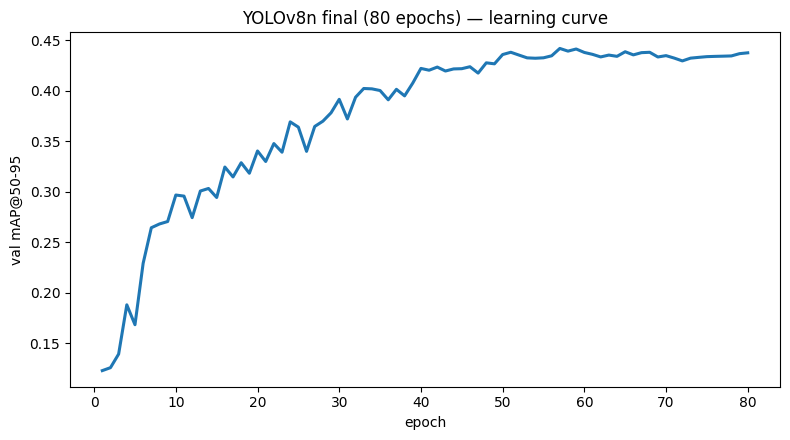

In [9]:
csvf = RUN_DIR / "results.csv"
if csvf.exists():
    d = pd.read_csv(csvf); d.columns = [c.strip() for c in d.columns]
    col = next((c for c in d.columns if "mAP50-95" in c), None)
    if col:
        plt.figure(figsize=(8, 4.5))
        plt.plot(d["epoch"], d[col], lw=2.2)
        plt.xlabel("epoch"); plt.ylabel("val mAP@50-95")
        plt.title("YOLOv8n final (80 epochs) — learning curve")
        plt.tight_layout(); plt.show()
else:
    print("results.csv not found yet.")